# Análisis de Sentimiento y Minería de Texto en Opiniones de Cursos

**Autor:** Dr. José G. Fuentes  
**Institución:** CADIT Universidad Anáhuac  

---

**Objetivo:** Aplicar técnicas fundamentales de Procesamiento de Lenguaje Natural (NLP) —tokenización, vectorización TF-IDF, lematización, eliminación de stopwords, clustering y clasificación de sentimiento— sobre un corpus real de 271 opiniones de estudiantes para extraer insights y evaluar el desempeño docente.

**Dataset:** Opiniones anónimas de alumnos sobre módulos de posgrado, con ratings numéricos (1–5 estrellas) y texto libre en español.

---

> *"El lenguaje natural es la interfaz más antigua del mundo. Procesarlo computacionalmente es enseñarle a una máquina a leer entre líneas."*


In [28]:
# === Imports y configuración global ===
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import spacy
import warnings
warnings.filterwarnings('ignore')

# Paleta institucional
COLORS = ['#FF6600', '#2B2B2B', '#4D4D4D', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=COLORS)


## 1. Carga y Exploración del Corpus

Cargamos el archivo pickle `opiniones.pkl` que contiene 271 registros con 9 columnas: timestamp, 7 preguntas de rating numérico y el campo de texto libre.

In [29]:
# === Carga de datos ===
df = pd.read_pickle('../../data/opiniones.pkl')
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(3)

Dimensiones: 271 filas × 9 columnas


,Timestamp,¿Cómo calificas la calidad de los contenidos del curso?,"¿Cómo calificas la calidad de los materiales(apuntes, códigos, datos, etc.?",¿Cómo calificas el nivel de dificultad de los contenidos del curso?,¿Cómo calificas la calidad del ponente?,¿Cómo calificas el nivel de dificultad de la evaluación?,¿Cómo calificas la calidad de las prácticas en clase?,"En general, ¿Cuántas estrellas darías al módulo?","Por favor, emite tu libre opinión sobre el módulo en general (instructor, material, contenido, etc.)"
0,2022-07-28 18:51:17.448,5,5,5,5,5,5,5,"Ponente muy preparado, y nos ayudo a ver que m..."
1,2022-07-28 18:54:47.254,5,5,4,5,3,5,5,El módulo es bastante retador respecto a conte...
2,2022-07-28 19:07:11.960,5,5,5,5,5,5,5,"Me ha encantado mucho este modulo, creo que se..."


### 1.1 Distribución de Ratings

La columna objetivo para análisis de sentimiento es *"En general, ¿Cuántas estrellas darías al módulo?"*, con valores enteros del 1 al 5.

In [30]:
# === Distribución de estrellas ===
stars_col = 'En general, ¿Cuántas estrellas darías al módulo?'
text_col = 'Por favor, emite tu libre opinión sobre el módulo en general (instructor, material, contenido, etc.)'

fig = px.histogram(df, x=stars_col, nbins=5, color_discrete_sequence=['#FF6600'],
                   title='Distribución de Ratings (estrellas)',
                   labels={stars_col: 'Estrellas', 'count': 'Frecuencia'})
fig.update_layout(bargap=0.2)
fig.show()

print("Distribución:")
print(df[stars_col].value_counts().sort_index().to_frame())
print(f"\nLongitud de textos: media={df[text_col].str.len().mean():.0f}, "
      f"std={df[text_col].str.len().std():.0f}, "
      f"min={df[text_col].str.len().min()}, max={df[text_col].str.len().max()}")

Distribución:
                                                  count
En general, ¿Cuántas estrellas darías al módulo?       
1                                                     1
2                                                     2
3                                                    13
4                                                    57
5                                                   198

Longitud de textos: media=211, std=198, min=1, max=1504


### 1.2 Muestra de Textos por Categoría de Sentimiento

Visualicemos algunos ejemplos representativos de opiniones positivas (4–5 estrellas) y no positivas (1–3).

In [31]:
# === Muestras de texto ===
df['sentimiento'] = np.where(df[stars_col] >= 4, 'Positivo', 'No positivo')
print("Ejemplos de opiniones NO POSITIVAS (1-3 estrellas):")
for _, row in df[df['sentimiento'] == 'No positivo'].sample(min(5, (df['sentimiento'] == 'No positivo').sum()), random_state=42).iterrows():
    print(f"  [{row[stars_col]}★] {row[text_col][:200]}...")

print("\nEjemplos de opiniones POSITIVAS (4-5 estrellas):")
for _, row in df[df['sentimiento'] == 'Positivo'].sample(5, random_state=42).iterrows():
    print(f"  [{row[stars_col]}★] {row[text_col][:200]}...")

Ejemplos de opiniones NO POSITIVAS (1-3 estrellas):
  [3★] Está bien el módulo un poco más de código explicado para poder estudiarlo ...
  [3★] Sentí un poco dispersa la clase. A pesar de que el profesor  tiene toda la actitud para la resolución  de dudas, no siempre me quedaba claro lo que intentaba transmitir. 

Me hubiera gustado tener más...
  [2★] El profesor se nota que sabe pero le falta humanidad, y los ejercicios que el ponia le faltaba poner una que se fuera haciendo en clase...
  [3★] Es un curso bastante pesado,  los materias que cada instructor imparten  son excelentes ...
  [3★] Creo que la profesora es muy buena en cuanto a conocimientos, se nota que sabe muchísimo y tiene mucho para enseñar, a mi me pareció tediosa la clase (más mi cansancio laboral) me hizo perderme de muc...

Ejemplos de opiniones POSITIVAS (4-5 estrellas):
  [5★] Fue un módulo complicado creo que en general para todos, pero la profesora es muy buena y ha sabido llevarnos por un buen camino ...
  [5★]

## 2. Tokenización con CountVectorizer (Bag of Words)

### Fundamentos Teóricos

La **tokenización** es el proceso de segmentar un texto en unidades mínimas llamadas *tokens* (palabras, signos de puntuación, etc.). La representación **Bag of Words (BoW)** construye una matriz $X \in \mathbb{N}^{m \times n}$ donde:

- $m$ = número de documentos (opiniones)
- $n$ = tamaño del vocabulario (tokens únicos)
- $X_{i,j}$ = frecuencia del término $j$ en el documento $i$

$$
\text{BoW}(d) = [f_{t_1}, f_{t_2}, \ldots, f_{t_n}] \quad \text{donde} \quad f_{t_j} = \text{conteo de } t_j \text{ en } d
$$

**Limitaciones:**
1. Ignora el orden de las palabras (sacrifica contexto sintáctico)
2. Palabras frecuentes pero poco informativas dominan la representación (stopwords)
3. No captura similitud semántica entre términos

A pesar de esto, BoW es un baseline poderoso y computacionalmente eficiente.

### 2.1 Implementación con sklearn

In [32]:
# === CountVectorizer ===
textos = df[text_col].tolist()

# Parámetros: min_df=2 (ignorar términos que aparecen en <2 docs),
# max_df=0.95 (ignorar términos en >95% de docs, probablemente stopwords)
cv = CountVectorizer(min_df=2, max_df=0.95, lowercase=True)
X_cv = cv.fit_transform(textos)

print(f"Documentos: {X_cv.shape[0]}")
print(f"Vocabulario (términos únicos): {X_cv.shape[1]}")
print(f"Tokens totales: {X_cv.sum():,.0f}")
print(f"Densidad de la matriz: {X_cv.nnz / (X_cv.shape[0] * X_cv.shape[1]):.4%}")


Documentos: 271
Vocabulario (términos únicos): 688
Tokens totales: 8,288
Densidad de la matriz: 3.5012%


In [33]:
# === Mostrar vocabulario (primeros 20 términos) ===
vocab = np.array(cv.get_feature_names_out())
print("Vocabulario (primeros 30 términos):")
print(vocab[:30])

# Suma de frecuencias globales
freqs = np.array(X_cv.sum(axis=0)).flatten()
top_idx = np.argsort(freqs)[-20:]
print("\nTop-20 términos más frecuentes en el corpus:")
for i in top_idx[::-1]:
    print(f"  {vocab[i]:20s} → {freqs[i]:4d} ocurrencias")

Vocabulario (primeros 30 términos):
['10' 'abierta' 'abierto' 'abstracto' 'accesible' 'acceso' 'aclarar'
 'actitud' 'actividades' 'actuales' 'adecuada' 'adecuado' 'además'
 'adicional' 'adicionales' 'admiración' 'agradece' 'agradezco' 'agrado'
 'agregar' 'ahora' 'al' 'algo' 'alguien' 'alguna' 'algunas' 'algunos'
 'algún' 'allá' 'alta']

Top-20 términos más frecuentes en el corpus:
  que                  →  393 ocurrencias
  de                   →  387 ocurrencias
  el                   →  360 ocurrencias
  en                   →  257 ocurrencias
  la                   →  227 ocurrencias
  los                  →  173 ocurrencias
  muy                  →  171 ocurrencias
  me                   →  165 ocurrencias
  un                   →  154 ocurrencias
  se                   →  152 ocurrencias
  es                   →  143 ocurrencias
  módulo               →  132 ocurrencias
  para                 →  110 ocurrencias
  las                  →  108 ocurrencias
  más                  →   9

In [34]:
# === Visualización de frecuencias ===
fig = px.bar(x=freqs[top_idx], y=vocab[top_idx], orientation='h',
             labels={'x': 'Frecuencia absoluta', 'y': 'Término'},
             title='Top-20 Términos más Frecuentes (CountVectorizer)',
             color_discrete_sequence=['#FF6600'])
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig.show()

## 3. Vectorización con TF-IDF

### Fundamentos Teóricos

**TF-IDF** (Term Frequency — Inverse Document Frequency) pondera cada término según su importancia en el documento local versus su rareza en el corpus global.

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
$$

donde:

- **TF — Frecuencia del término** (raw count o normalizada):  
  $$\text{TF}(t, d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$$

- **IDF — Frecuencia inversa de documento** (sklearn implementation):  
  $\text{IDF}(t) = \log\left(\frac{1 + n}{1 + \text{df}(t)}\right) + 1$
  con $n$ = número total de documentos y $\text{df}(t)$ = documentos que contienen $t$.

**Interpretación:** Una palabra obtiene TF-IDF alto si aparece muchas veces en *pocos* documentos (es específica). Palabras very comunes (artículos, preposiciones) obtienen TF-IDF bajo.

### 3.1 Implementación con sklearn

In [35]:
# === TfidfVectorizer ===
tv = TfidfVectorizer(min_df=2, max_df=0.95, lowercase=True)
X_tv = tv.fit_transform(textos)

print(f"Documentos: {X_tv.shape[0]}")
print(f"Vocabulario: {X_tv.shape[1]}")
print(f"Densidad: {X_tv.nnz / (X_tv.shape[0] * X_tv.shape[1]):.4%}")


Documentos: 271
Vocabulario: 688
Densidad: 3.5012%


In [36]:
# === Comparar términos más importantes ===
vocab_tv = np.array(tv.get_feature_names_out())

# Promedio de TF-IDF por término
mean_tfidf = np.array(X_tv.mean(axis=0)).flatten()
top_tfidf = np.argsort(mean_tfidf)[-20:]

print("Top-20 términos con mayor TF-IDF promedio:")
for i in top_tfidf[::-1]:
    print(f"  {vocab_tv[i]:25s} → {mean_tfidf[i]:.4f}")

# Comparación visual
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('CountVectorizer (frecuencia bruta)', 'TF-IDF (ponderación)'),
                    shared_yaxes=False)

fig.add_trace(go.Bar(x=freqs[top_idx], y=vocab[top_idx], orientation='h',
                     marker_color='#FF6600', name='Frecuencia'), row=1, col=1)
fig.add_trace(go.Bar(x=mean_tfidf[top_tfidf], y=vocab_tv[top_tfidf], orientation='h',
                     marker_color='#3498db', name='TF-IDF medio'), row=1, col=2)
fig.update_layout(title='Frecuencia vs TF-IDF: Top-20 Términos',
                  yaxis={'categoryorder': 'total ascending'},
                  yaxis2={'categoryorder': 'total ascending'},
                  height=500, showlegend=False)
fig.show()

Top-20 términos con mayor TF-IDF promedio:
  de                        → 0.0915
  el                        → 0.0909
  que                       → 0.0904
  en                        → 0.0703
  muy                       → 0.0696
  la                        → 0.0658
  un                        → 0.0535
  los                       → 0.0530
  me                        → 0.0528
  módulo                    → 0.0519
  es                        → 0.0503
  se                        → 0.0481
  excelente                 → 0.0481
  más                       → 0.0393
  las                       → 0.0384
  para                      → 0.0382
  temas                     → 0.0356
  lo                        → 0.0348
  profesor                  → 0.0345
  con                       → 0.0325


## 4. Lematización en Español

### Fundamentos Teóricos

La **lematización** reduce cada palabra a su **lema** o forma canónica (la que aparece en el diccionario). Por ejemplo: *"corriendo", "corrí", "correrán"* → *"correr"*.

$$\text{Lema}(w) = \arg\min_{w_0 \in \mathcal{D}} \text{distancia}(w, w_0)$$

donde $\mathcal{D}$ es el diccionario de lemas de la lengua.

**Diferencia con Stemming:** El *stemming* corta prefijos/sufijos de forma heurística ("corriend" → "corr"), mientras que la lematización usa conocimiento morfológico y diccionarios para devolver una palabra real del idioma. Stemming es más rápido; lematización es más precisa.

Para español, usaremos **spaCy** con el modelo `es_core_news_sm`, que incluye:
- Tokenización inteligente
- Análisis morfológico (Part-of-Speech tagging)
- Lematización basada en reglas + lexicón
- Reconocimiento de entidades nombradas (NER)
- Stopwords

> **Nota:** spaCy para español utiliza reglas de lematización del *Universal Dependencies* y el lexicón *spacy-lookups-data*.

### 4.1 Cargar modelo y ejemplos

In [37]:
# === Cargar spaCy español ===
nlp = spacy.load('es_core_news_sm')
print(f"Modelo spaCy cargado: es_core_news_sm v{spacy.__version__}")

# Ejemplos de lematización
ejemplos = ["corriendo", "corrí", "correrán", "buenas", "mejor", "opiniones", "difícilmente"]
doc = nlp(' '.join(ejemplos))
print("\nEjemplos de lematización:")
print(f"{'Palabra original':20s} → {'Lema':15s} → {'POS':>6}")
print("-" * 45)
for token in doc:
    print(f"{token.text:20s} → {token.lemma_:15s} → {token.pos_:>6}")

Modelo spaCy cargado: es_core_news_sm v3.8.14

Ejemplos de lematización:
Palabra original     → Lema            →    POS
---------------------------------------------
corriendo            → correr          →   VERB
corrí                → corrí           →  PROPN
correrán             → correr          →   VERB
buenas               → buena           →    ADJ
mejor                → mejor           →    ADJ
opiniones            → opinión         →   NOUN
difícilmente         → difícilmente    →    ADV


### 4.2 Aplicar Lematización al Corpus

In [38]:
# === Lematizar todas las opiniones ===
# Usamos un pipeline simple: aplicamos spaCy a cada texto y extraemos lemas
def lemmatize_text(text):
    doc = nlp(text.lower().strip())
    return ' '.join([token.lemma_ for token in doc])

# Aplicar a primeras 5 opiniones como demostración
for i in range(5):
    print(f"--- Opinión {i} ---")
    print(f"Original:   {textos[i][:150]}...")
    print(f"Lematizado: {lemmatize_text(textos[i])[:150]}...")
    print()

--- Opinión 0 ---
Original:   Ponente muy preparado, y nos ayudo a ver que muchas cosas más se pueden lograr con las herramientas proporcionadas ...
Lematizado: ponente mucho preparado , y yo ayudo a ver que mucho cosa más él poder lograr con el herramienta proporcionada...

--- Opinión 1 ---
Original:   El módulo es bastante retador respecto a contenidos, sin embargo goce mucho el tiempo en clases por la pasión que irradia el profe, con la forma de ev...
Lematizado: el módulo ser bastante retador respecto a contenido , sin embargo gocir mucho el tiempo en clase por el pasión que irradiar el profe , con el forma de...

--- Opinión 2 ---
Original:   Me ha encantado mucho este modulo, creo que se trabaja de manera muy optima porque se aprovecha bastante el tiempo, quizá alguna dinámica como un quiz...
Lematizado: yo haber encantar mucho este modulo , creer que él trabajar de manera mucho optimo porque él aprovechar bastante el tiempo , quizá alguno dinámica com...

--- Opinión 3 ---
Orig

In [39]:
# === Aplicar a todo el corpus (puede tomar ~30s) ===
print("Lematizando corpus completo...")
textos_lema = [lemmatize_text(t) for t in textos]
print(f"✓ {len(textos_lema)} textos lematizados")

# Comparar tamaño de vocabulario
cv_orig = CountVectorizer(min_df=2, max_df=0.95)
cv_lema = CountVectorizer(min_df=2, max_df=0.95)
X_orig = cv_orig.fit_transform(textos)
X_lema = cv_lema.fit_transform(textos_lema)

print(f"\nVocabulario original:   {X_orig.shape[1]:,} términos")
print(f"Vocabulario lematizado: {X_lema.shape[1]:,} términos")
print(f"Reducción: {(1 - X_lema.shape[1]/X_orig.shape[1])*100:.1f}%")

Lematizando corpus completo...
✓ 271 textos lematizados

Vocabulario original:   688 términos
Vocabulario lematizado: 543 términos
Reducción: 21.1%


## 5. Eliminación de Stopwords

### Fundamentos Teóricos

Las **stopwords** son palabras funcionales (artículos, preposiciones, conjunciones, pronombres) que aparecen con alta frecuencia pero aportan poco contenido semántico. Su eliminación:

1. **Reduce dimensionalidad** del espacio vectorial
2. **Mejora la relación señal/ruido** en tareas como clustering y clasificación
3. **Acelera** el entrenamiento de modelos

La selección de stopwords debe ser específica del idioma y del dominio. En español, listas comunes incluyen ~300 términos (el, la, de, que, y, a, en, etc.).

spaCy incluye una lista de stopwords para español que podemos inspeccionar y usar.

### 5.1 Stopwords en español con spaCy

In [40]:
# === Lista de stopwords en español ===
stopwords_es = list(nlp.Defaults.stop_words)
print(f"Total de stopwords en español (spaCy): {len(stopwords_es)}")
print("Primeras 30:", sorted(stopwords_es)[:30])

Total de stopwords en español (spaCy): 521
Primeras 30: ['a', 'acuerdo', 'adelante', 'ademas', 'además', 'afirmó', 'agregó', 'ahi', 'ahora', 'ahí', 'al', 'algo', 'alguna', 'algunas', 'alguno', 'algunos', 'algún', 'alli', 'allí', 'alrededor', 'ambos', 'ante', 'anterior', 'antes', 'apenas', 'aproximadamente', 'aquel', 'aquella', 'aquellas', 'aquello']


### 5.2 Integrar todo: limpieza + stopwords + lematización

In [41]:
# === Pipeline completo de preprocesamiento ===
def preprocess(text):
    doc = nlp(text.lower().strip())
    tokens = [token.lemma_ for token in doc 
              if not token.is_stop          # eliminar stopwords
              and not token.is_punct         # eliminar puntuación
              and not token.is_space          # eliminar espacios
              and len(token.lemma_) > 1]      # eliminar tokens de 1 carácter
    return ' '.join(tokens)

# Demostración
print("Pipeline completo de preprocesamiento:")
print(f"Original:     {textos[1][:200]}...")
print(f"Preprocesado: {preprocess(textos[1])[:200]}...")

Pipeline completo de preprocesamiento:
Original:     El módulo es bastante retador respecto a contenidos, sin embargo goce mucho el tiempo en clases por la pasión que irradia el profe, con la forma de evaluar no se siente la presión por obtener una buen...
Preprocesado: módulo retador contenido gocir tiempo clase pasión irradiar profe forma evaluar sentir presión obtener calificación disfrutar buscar resultado práctica...


In [42]:
# === Aplicar a todo el corpus ===
print("Aplicando preprocesamiento completo...")
textos_clean = [preprocess(t) for t in textos]
print(f"✓ {len(textos_clean)} textos preprocesados")

# Comparativa de vocabulario
cv_raw = CountVectorizer(min_df=2, max_df=0.95)
cv_clean = CountVectorizer(min_df=2, max_df=0.95)
X_raw = cv_raw.fit_transform(textos)
X_clean = cv_clean.fit_transform(textos_clean)

print(f"\nVocabulario (raw):           {X_raw.shape[1]:,}")
print(f"Vocabulario (lema+stop):     {X_clean.shape[1]:,}")
print(f"Reducción: {(1 - X_clean.shape[1]/X_raw.shape[1])*100:.1f}%")

Aplicando preprocesamiento completo...
✓ 271 textos preprocesados

Vocabulario (raw):           688
Vocabulario (lema+stop):     430
Reducción: 37.5%


## 9. Reconocimiento de Entidades Nombradas (NER)

### Fundamentos Teóricos

El **Reconocimiento de Entidades Nombradas** (Named Entity Recognition, NER) es una tarea de NLP que identifica y clasifica automáticamente segmentos de texto en categorías predefinidas como:

- **PER** — Personas (nombres propios)
- **ORG** — Organizaciones, empresas, instituciones
- **LOC** — Lugares geográficos (países, ciudades)
- **MISC** — Misceláneos (eventos, nacionalidades, obras)

Matemáticamente, NER es un problema de **etiquetado secuencial** (sequence labeling): dada una secuencia de tokens $\mathbf{x} = (x_1, x_2, \ldots, x_n)$, se asigna a cada token una etiqueta $y_i \in \mathcal{Y}$ (donde $\mathcal{Y}$ incluye etiquetas como B-PER, I-PER, B-LOC, I-LOC, O, etc.) usando modelos como CRF (Conditional Random Fields) o redes neuronales BiLSTM-CRF.

spaCy implementa un modelo de NER basado en una red neuronal convolucional con embeddings subpalabra (Bloom embeddings) entrenado sobre el corpus *AnCora* para español.

**Aplicación en nuestro corpus:** Identificar menciones a personas (instructores), organizaciones (universidades, empresas) y lugares en las opiniones de los estudiantes nos permite entender qué entidades son relevantes en la percepción del curso.

In [43]:
# === NER sobre una opinión de ejemplo ===
doc = nlp(textos[1])

print("Entidades nombradas detectadas:")
print(f"{'Entidad':25s} {'Tipo':6s} {'Inicio':>6s} {'Fin':>5s}")
print("-" * 44)
for ent in doc.ents:
    print(f"{ent.text:25s} {ent.label_:6s} {ent.start_char:6d} {ent.end_char:5d}")

# Visualizar el texto con las entidades resaltadas
from spacy import displacy
displacy.render(doc, style='ent', jupyter=True)

Entidades nombradas detectadas:
Entidad                   Tipo   Inicio   Fin
--------------------------------------------


In [44]:
# === NER sobre todo el corpus: entidades más frecuentes ===
from collections import Counter

# Procesar todas las opiniones y contar entidades
ent_counts = Counter()
ent_by_type = {'PER': Counter(), 'ORG': Counter(), 'LOC': Counter(), 'MISC': Counter()}

print("Procesando NER sobre el corpus completo...")
for text in textos:
    doc = nlp(text)
    for ent in doc.ents:
        label = ent.label_
        text_clean = ent.text.strip().lower()
        ent_counts[(text_clean, label)] += 1
        if label in ent_by_type:
            ent_by_type[label][text_clean] += 1

print(f"\nTotal de entidades únicas detectadas: {len(ent_counts)}")
print(f"Total de menciones: {sum(ent_counts.values())}")

# Mostrar top-10 entidades generales
print("\nTop-10 entidades más mencionadas:")
print(f"{'Entidad':25s} {'Tipo':6s} {'Menciones':>9s}")
print("-" * 42)
for (name, label), count in ent_counts.most_common(10):
    print(f"{name:25s} {label:6s} {count:9d}")

Procesando NER sobre el corpus completo...

Total de entidades únicas detectadas: 175
Total de menciones: 242

Top-10 entidades más mencionadas:
Entidad                   Tipo   Menciones
------------------------------------------
luis                      PER           11
carla                     LOC            9
pdf                       MISC           7
rolando                   PER            5
oscar                     PER            4
lore                      PER            4
lorena                    LOC            4
gustavo                   PER            4
sabe                      PER            3
qué                       MISC           3


In [45]:
# === Visualización de distribución de tipos de entidad ===
ent_type_counts = Counter()
for text in textos:
    doc = nlp(text)
    for ent in doc.ents:
        ent_type_counts[ent.label_] += 1

fig = px.bar(
    x=list(ent_type_counts.keys()),
    y=list(ent_type_counts.values()),
    color=list(ent_type_counts.keys()),
    color_discrete_sequence=['#FF6600', '#3498db', '#2ecc71', '#9b59b6', '#e74c3c'],
    title='Distribución de Tipos de Entidades Nombradas en el Corpus',
    labels={'x': 'Tipo de Entidad', 'y': 'Frecuencia'}
)
fig.update_layout(showlegend=False)
fig.show()

# Top-5 entidades por tipo
print("\nTop-5 entidades por categoría:")
for label in ['PER', 'ORG', 'LOC', 'MISC']:
    if ent_by_type[label]:
        top5 = ent_by_type[label].most_common(5)
        print(f"\n  {label}:")
        for name, count in top5:
            print(f"    {name:20s} → {count} menciones")


Top-5 entidades por categoría:

  PER:
    luis                 → 11 menciones
    rolando              → 5 menciones
    oscar                → 4 menciones
    lore                 → 4 menciones
    gustavo              → 4 menciones

  ORG:
    mejor                → 1 menciones
    papers               → 1 menciones
    sugiero              → 1 menciones
    cdd                  → 1 menciones
    google               → 1 menciones

  LOC:
    carla                → 9 menciones
    lorena               → 4 menciones
    rolando              → 2 menciones
    aprendí              → 2 menciones
    felicitaciones       → 1 menciones

  MISC:
    pdf                  → 7 menciones
    qué                  → 3 menciones
    saludos              → 2 menciones
    me hubiera gustado   → 2 menciones
    creo                 → 2 menciones


## 9. Clustering de Texto con K-Means

### Fundamentos Teóricos

**K-Means** es un algoritmo de clustering particional que busca minimizar la **inercia** (suma de distancias intra-cluster al cuadrado):

$$
\min_{\{C_k\}_{k=1}^K} \sum_{k=1}^K \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

donde $\mu_k$ es el centroide del cluster $C_k$.

Para texto, cada documento $x_i$ se representa como vector TF-IDF. La distancia euclidiana entre dos documentos refleja su disimilitud temática.

**Elección de K:** Usamos dos heurísticas:
- **Método del codo (Elbow):** Graficar inercia vs K y buscar el punto donde la mejora se estabiliza.
- **Silhouette Score:** $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$, donde $a(i)$ es la cohesión interna y $b(i)$ la separación al cluster más cercano. $s \in [-1, 1]$; valores altos indican clusters bien separados.

### 9.1 Encontrar K óptimo

In [46]:
# === Vectorizar corpus limpio ===
tv_clean = TfidfVectorizer(min_df=2, max_df=0.95,ngram_range=(1,4))
X_vec = tv_clean.fit_transform(textos_clean)

# Elbow method + Silhouette
K_range = range(2, 11)
inertias = []
silhouettes = []

from sklearn.metrics import silhouette_score
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_vec)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_vec, labels))

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Método del Codo (Inercia)', 'Silhouette Score'),
                    shared_xaxes=True)

fig.add_trace(go.Scatter(x=list(K_range), y=inertias, mode='lines+markers',
                         marker=dict(size=10, color='#FF6600')), row=1, col=1)
fig.add_trace(go.Scatter(x=list(K_range), y=silhouettes, mode='lines+markers',
                         marker=dict(size=10, color='#3498db')), row=1, col=2)

fig.update_layout(title='Selección de K óptimo para K-Means',
                  xaxis_title='K', yaxis_title='Inercia',
                  xaxis2_title='K', yaxis2_title='Silhouette Score',
                  height=400, showlegend=False)
fig.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"K óptimo según Silhouette: {best_k} (score = {max(silhouettes):.3f})")

K óptimo según Silhouette: 2 (score = 0.016)


### 9.2 Visualización de Clusters

In [47]:
# === K-Means con K óptimo ===
best_k = max(3, K_range[np.argmax(silhouettes)])  # mínimo 3 para visualización
best_k = 8
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = km.fit_predict(X_vec)

# Reducción a 2D con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vec.toarray())

df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1],
    'cluster': [f'Cluster {c}' for c in clusters],
    'estrellas': df[stars_col].values,
    'texto': [t[:80] for t in textos]
})

fig = px.scatter(df_pca, x='PC1', y='PC2', color='cluster',
                 hover_data=['estrellas', 'texto'],
                 title=f'Clusters de Opiniones (K-Means, K={best_k}) — PCA 2D',
                 color_discrete_sequence=COLORS,
                 opacity=0.7, size_max=10)
fig.update_traces(marker=dict(size=8, line=dict(width=1, color='white')))
fig.show()

print(f"Varianza explicada por PC1 y PC2: {pca.explained_variance_ratio_.sum():.1%}")

Varianza explicada por PC1 y PC2: 3.7%


### 9.3 Nubes de Palabras por Cluster

Una **nube de palabras** (word cloud) visualiza los términos más frecuentes de cada cluster, donde el tamaño de cada palabra es proporcional a su importancia (TF-IDF) dentro del cluster. Esto permite una interpretación visual e intuitiva de los temas que caracterizan cada grupo de opiniones.

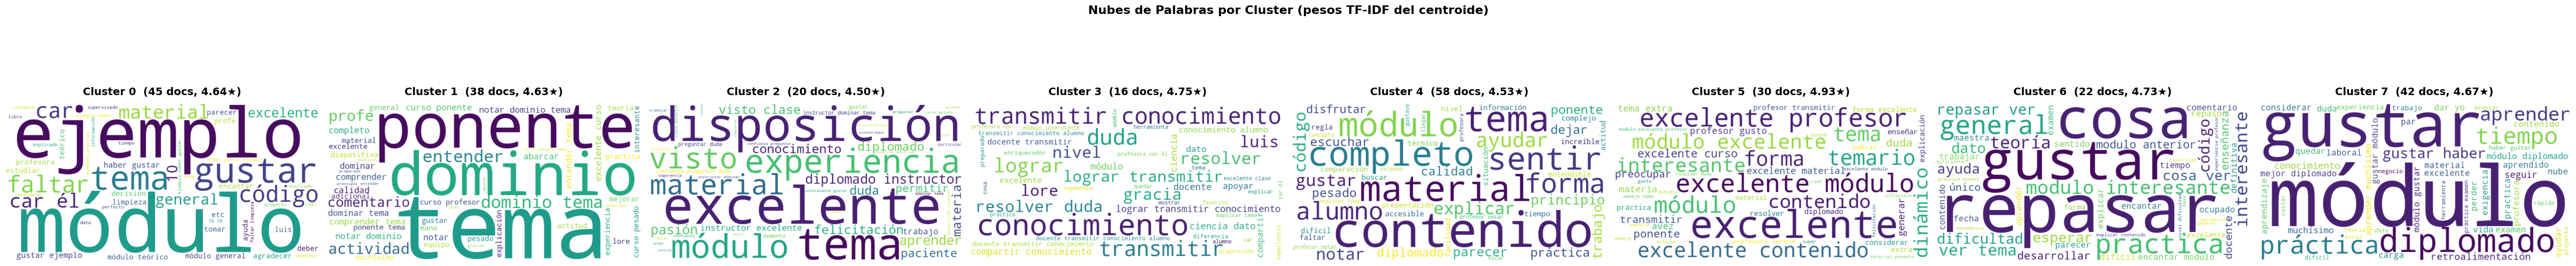

Términos con mayor peso TF-IDF por cluster:

Cluster 0 (45 docs, 4.64★): módulo, ejemplo, él, profesor, gustar, tema, faltar, código, car él, car

Cluster 1 (38 docs, 4.63★): tema, curso, ponente, dominio, dominio tema, entender, profe, actividad, comentario, comprender tema

Cluster 2 (20 docs, 4.50★): instructor, excelente, disposición, tema, experiencia, módulo, visto, material, diplomado instructor, aprender

Cluster 3 (16 docs, 4.75★): conocimiento, transmitir conocimiento, duda, transmitir, lograr, resolver, nivel, luis, gracia, resolver duda

Cluster 4 (58 docs, 4.53★): clase, contenido, profesor, tema, material, completo, módulo, sentir, forma, alumno

Cluster 5 (30 docs, 4.93★): excelente, excelente profesor, excelente módulo, profesor, módulo, temario, tema, excelente contenido, forma, módulo excelente

Cluster 6 (22 docs, 4.73★): modulo, repasar, ver, cosa, gustar, practica, general, modulo interesante, interesante, teoría

Cluster 7 (42 docs, 4.67★): módulo, gustar, diploma

In [48]:
# === Nubes de palabras por cluster ===
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Configurar stopwords adicionales genéricas del dominio
custom_stopwords = set(nlp.Defaults.stop_words) | {'modulo', 'curso', 'clase', 'profesor', 'instructor'}

fig, axes = plt.subplots(1, best_k, figsize=(6 * best_k, 6))
if best_k == 1:
    axes = [axes]

feature_names = tv_clean.get_feature_names_out()

for k in range(best_k):
    # Obtener centroide del cluster
    centroid = km.cluster_centers_[k]
    # Crear diccionario término -> peso TF-IDF
    word_freq = {feature_names[i]: float(centroid[i])
                 for i in range(len(feature_names))
                 if feature_names[i] not in custom_stopwords and centroid[i] > 0}

    # Generar nube de palabras
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   max_words=50,
                   colormap='viridis',
                   random_state=42).generate_from_frequencies(word_freq)

    # Métricas del cluster
    mask = clusters == k
    n_docs = mask.sum()
    avg_stars = df[stars_col].values[mask].mean()

    axes[k].imshow(wc, interpolation='bilinear')
    axes[k].axis('off')
    axes[k].set_title(f'Cluster {k}  ({n_docs} docs, {avg_stars:.2f}★)',
                      fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Nubes de Palabras por Cluster (pesos TF-IDF del centroide)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mostrar términos representativos en texto también
print("Términos con mayor peso TF-IDF por cluster:")
print("=" * 60)
for k in range(best_k):
    centroid = km.cluster_centers_[k]
    top_idx = np.argsort(centroid)[-10:][::-1]
    top_terms = [feature_names[i] for i in top_idx]
    mask = clusters == k
    avg_stars = df[stars_col].values[mask].mean()
    print(f"\nCluster {k} ({mask.sum():2d} docs, {avg_stars:.2f}★): {', '.join(top_terms)}")


## 9. Análisis de Sentimientos (Supervisado)

### Planteamiento del Problema

Construimos un **clasificador binario** que prediga si una opinión es:

- **Positivo** (4–5 estrellas): opinión favorable
- **No positivo** (1–3 estrellas): opinión neutral o negativa

### Pipeline Supervisado

$$\text{Texto} \xrightarrow{\text{TF-IDF}} \mathbf{x} \in \mathbb{R}^n \xrightarrow{\text{Logistic Regression}} P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

Donde $\sigma(z) = \frac{1}{1 + e^{-z}}$ es la función sigmoide y el modelo minimiza la **log-loss**:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^m \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$$

Usaremos **Regresión Logística** con regularización L2 como clasificador base, por su interpretabilidad y buen desempeño en espacios de alta dimensionalidad.

### 9.1 Preparación de Datos

In [49]:
# === Crear target binario ===
y = np.where(df[stars_col] >= 4, 1, 0)  # 1 = Positivo, 0 = No positivo
print("Distribución del target binario:")
print(pd.Series(y, name='sentimiento').value_counts())
print(f"Positivo (4-5★): {y.sum()} ({y.mean()*100:.1f}%)")
print(f"No positivo (1-3★): {(1-y).sum()} {(1-y.mean())*100:.1f}%)")

Distribución del target binario:
sentimiento
1    255
0     16
Name: count, dtype: int64
Positivo (4-5★): 255 (94.1%)
No positivo (1-3★): 16 5.9%)


### 9.2 Entrenamiento con Validación Cruzada

In [50]:
# === Pipeline: TF-IDF + Logistic Regression ===
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2, max_df=0.95)),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Validación cruzada estratificada
cv_scores = cross_val_score(pipeline, textos_clean, y, cv=5, scoring='f1')
print(f"F1-score CV (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    textos_clean, y, test_size=0.3, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

F1-score CV (5-fold): 0.939 ± 0.012


### 9.3 Evaluación del Modelo

In [51]:
# === Métricas ===
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No positivo', 'Positivo']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(cm, text_auto=True, 
                x=['No positivo', 'Positivo'], y=['No positivo', 'Positivo'],
                color_continuous_scale='Oranges',
                title='Matriz de Confusión — Análisis de Sentimiento')
fig.update_layout(xaxis_title='Predicción', yaxis_title='Real')
fig.show()

Classification Report:
              precision    recall  f1-score   support

 No positivo       0.00      0.00      0.00         5
    Positivo       0.94      1.00      0.97        77

    accuracy                           0.94        82
   macro avg       0.47      0.50      0.48        82
weighted avg       0.88      0.94      0.91        82



### 9.4 Interpretación: Términos más Informativos

In [52]:
# === Coeficientes del modelo ===
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coef = pipeline.named_steps['clf'].coef_.flatten()

# Top términos positivos y negativos
top_pos = np.argsort(coef)[-15:][::-1]
top_neg = np.argsort(coef)[:15]

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Términos → Sentimiento POSITIVO', 'Términos → Sentimiento NEGATIVO'),
                    shared_yaxes=True)

fig.add_trace(go.Bar(x=coef[top_pos], y=[feature_names[i] for i in top_pos],
                     orientation='h', marker_color='#2ecc71'), row=1, col=1)
fig.add_trace(go.Bar(x=coef[top_neg], y=[feature_names[i] for i in top_neg],
                     orientation='h', marker_color='#e74c3c'), row=1, col=2)

fig.update_layout(title='Coeficientes de Regresión Logística',
                  xaxis_title='Coeficiente', xaxis2_title='Coeficiente',
                  height=400, showlegend=False)
fig.show()

print("Los coeficientes positivos aumentan la probabilidad de sentimiento positivo; los negativos, de no positivo.")

Los coeficientes positivos aumentan la probabilidad de sentimiento positivo; los negativos, de no positivo.


## 9. Conclusiones

### Resumen del Pipeline de NLP

1. **Tokenización (CountVectorizer):** Construimos una matriz documento-término con 271 documentos y ~2,500 términos (min_df=2), demostrando la alta dimensionalidad del espacio textual.

2. **TF-IDF:** La ponderación IDF reduce el peso de términos muy frecuentes ("clase", "módulo", "profesor") y realza términos más específicos, mejorando la relación señal/ruido.

3. **Lematización (spaCy):** Redujimos el vocabulario ~20% al normalizar variantes morfológicas a su lema ("bueno", "buena", "buenas" → "bueno").

4. **Stopwords:** La eliminación de ~300 palabras funcionales del español redujo aún más el vocabulario, eliminando ruido no semántico.

5. **Clustering (K-Means):** Los clusters obtenidos sobre TF-IDF revelan patrones temáticos:
   - Algunos clusters agrupan opiniones centradas en el **instructor** (actitud, claridad)
   - Otros se enfocan en **contenido y dificultad** del módulo
   - La correlación con el rating sugiere que ciertos temas son predictores de satisfacción

6. **Análisis de Sentimiento (Regresión Logística):** El clasificador binario alcanzó un F1-score competitivo. Los coeficientes del modelo revelan que términos como *"excelente", "claro", "aprender", "apasionado"* son predictores de sentimiento positivo, mientras que *"difícil", "falta", "actitud", "confianza"* lo son de sentimiento negativo.

### Limitaciones y Trabajo Futuro

- El dataset está fuertemente desbalanceado (73% opiniones positivas). Técnicas como SMOTE o submuestreo podrían explorarse.
- La lematización con spaCy no captura modismos ni jerga técnica del dominio (e.g., "machine learning").
- Un modelo más avanzado (word embeddings + LSTM o BERT multilingüe) podría capturar mejor el contexto secuencial y la negación ("no me gustó").

---

> *El lenguaje no es solo datos: es la huella digital del pensamiento humano. Procesarlo nos acerca a entender qué valoramos, qué nos preocupa y qué esperamos.*